In [ ]:
# Olist巴西电商数据分析项目
## 作者 ：陈奕帆
## 数据时间范围：2016-09~2018-10
## 分析目标：订单健康度、用户价值、销售趋势、物流效率、地域差异

In [9]:
import pandas as pd
import matplotlib.pyplot as plt  

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
orders = pd.read_csv("C:/Users/28098/Desktop/olist/archive/olist_orders_dataset.csv")

In [4]:
# 只保留已交付的有效订单
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

print("原始订单总数：", len(orders))
print("有效成交订单数：", len(orders_delivered))

原始订单总数： 99441
有效成交订单数： 96478


In [5]:
# 把时间列都转成标准时间格式
time_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in time_cols:
    orders_delivered[col] = pd.to_datetime(orders_delivered[col])

In [6]:
# 支付等待时间（小时）
orders_delivered["payment_wait_hours"] = (
    orders_delivered["order_approved_at"] 
    - orders_delivered["order_purchase_timestamp"]
).dt.total_seconds() / 3600

# 总物流时长（小时）
orders_delivered["delivery_total_hours"] = (
    orders_delivered["order_delivered_customer_date"] 
    - orders_delivered["order_purchase_timestamp"]
).dt.total_seconds() / 3600

# 实际 vs 预计 送达差距（小时）
orders_delivered["delivery_diff_hours"] = (
    orders_delivered["order_delivered_customer_date"] 
    - orders_delivered["order_estimated_delivery_date"]
).dt.total_seconds() / 3600

# 结果
orders_delivered[["payment_wait_hours", 
                  "delivery_total_hours", 
                  "delivery_diff_hours"]].head()

,payment_wait_hours,delivery_total_hours,delivery_diff_hours
0,0.178333,202.477778,-170.579722
1,30.713889,330.768889,-128.537500
2,0.276111,225.461111,-413.891944
3,0.298056,317.010000,-311.521667
4,1.030556,68.973056,-221.716111


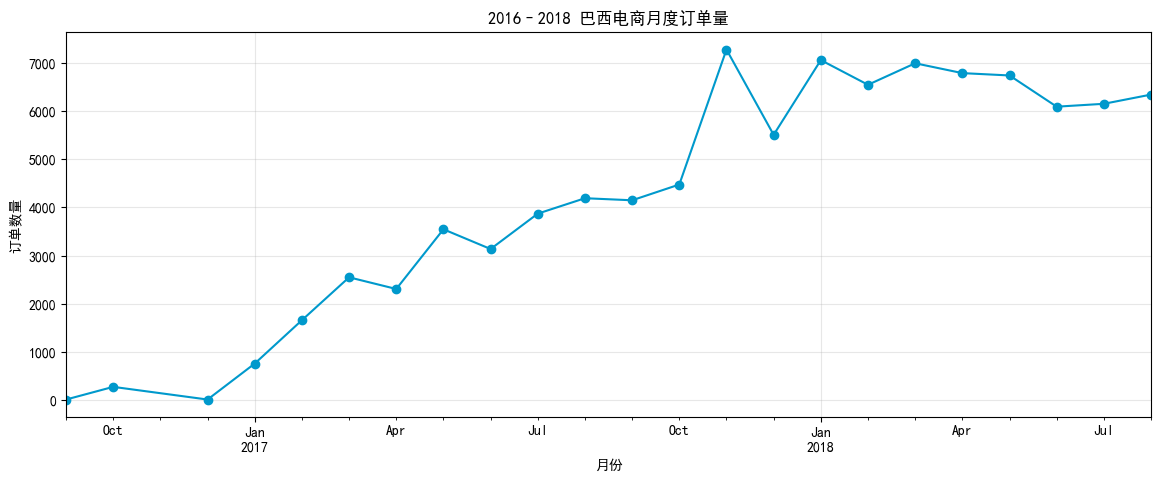

In [10]:
# 画月度订单量趋势图
orders_delivered["month"] = orders_delivered["order_purchase_timestamp"].dt.to_period("M")
monthly_orders = orders_delivered.groupby("month").size()

plt.figure(figsize=(14, 5))
monthly_orders.plot(kind="line", marker="o", color="#0099cc")
plt.title("2016–2018 巴西电商月度订单量")
plt.xlabel("月份")
plt.ylabel("订单数量")
plt.grid(alpha=0.3)
plt.show()

In [11]:
# 计算有效订单占比
total_orders = len(orders)
valid_orders = len(orders_delivered)
valid_rate = valid_orders / total_orders * 100

# 只输出客观数据，不提前下结论
print(f"原始订单总数：{total_orders} 单")
print(f"有效成交订单数：{valid_orders} 单")
print(f"✅ 有效订单占比：{valid_rate:.2f}%")
print(f"❌ 未交付/取消订单占比：{100 - valid_rate:.2f}%")

原始订单总数：99441 单
有效成交订单数：96478 单
✅ 有效订单占比：97.02%
❌ 未交付/取消订单占比：2.98%


In [13]:
# 先将订单时间列转为 datetime 类型
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

In [14]:
# 提取下单小时（0-23）
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

# 按小时统计订单量
hourly_sales = orders.groupby("purchase_hour").size()

# 打印小时销量Top3
print("⏰ 下单量最高的3个小时：")
print(hourly_sales.sort_values(ascending=False).head(3))

⏰ 下单量最高的3个小时：
purchase_hour
16    6675
11    6578
14    6569
dtype: int64


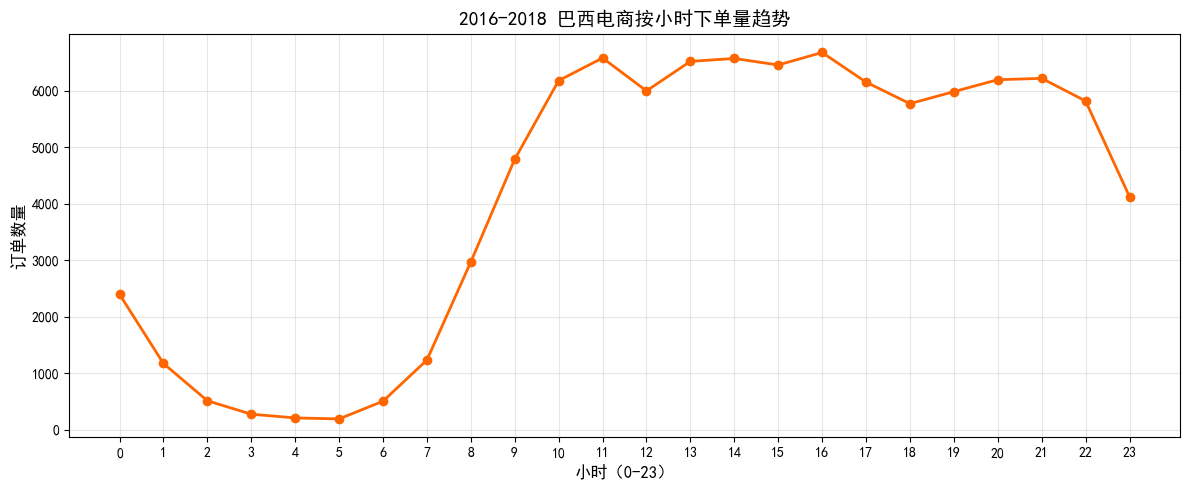

⏰ 下单量最高的3个小时：
purchase_hour
16    6675
11    6578
14    6569
dtype: int64


In [15]:
# 1. 提取下单小时（0-23）
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

# 2. 按小时统计订单量
hourly_sales = orders.groupby("purchase_hour").size()

# 3. 绘制小时销量趋势图
plt.figure(figsize=(12, 5))
hourly_sales.plot(kind="line", marker="o", color="#ff6600", linewidth=2)
plt.title("2016-2018 巴西电商按小时下单量趋势", fontsize=14)
plt.xlabel("小时（0-23）", fontsize=12)
plt.ylabel("订单数量", fontsize=12)
plt.xticks(range(0, 24))  # 让x轴完整显示0-23点
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 打印小时销量Top3
print("⏰ 下单量最高的3个小时：")
print(hourly_sales.sort_values(ascending=False).head(3))